# 3D image classification from CT scans

**Credit:** Adapted from the Keras example [3D image classification from CT scans](https://keras.io/examples/vision/3D_image_classification/) [1]. The data split, preprocessing, augmentation, model, hyperparameter search, training and evaluation have been reworked.

## Introduction
This example will show the steps needed to build a 3D convolutional neural network (CNN) to predict the presence of viral pneumonia in computer tomography (CT) scans. 2D CNNs are commonly used to process RGB images (3 channels). A 3D CNN is simply the 3D equivalent: it takes as input a 3D volume or a sequence of 2D frames (e.g. slices in a CT scan). 3D CNNs are a powerful model for learning representations for volumetric data.

Compared with the original example [1], this notebook:
- splits the scans into train, validation and test sets with a fixed seed. The validation set drives early stopping, checkpointing and the hyperparameter search; the test set is only used for the final evaluation.
- augments the training scans with rotation, zoom, contrast changes and noise, as TensorFlow ops that run in parallel in the `tf.data` pipeline.
- normalizes with group normalization instead of batch normalization, whose batch statistics are unreliable at a batch size of 2.
- searches over the learning rate, weight decay, dropout and network width with KerasTuner, judged on validation loss, then trains the best configuration from scratch.
- reports accuracy, sensitivity, specificity and ROC AUC on the test set, with bootstrap confidence intervals.

Training is slow. On an Apple M1 with the PyTorch backend, which uses the M1's GPU, an epoch takes about 1.5 minutes at the default width of 32 filters, and in a 20-epoch test run the validation loss was still falling. Training the final model for up to 200 epochs can therefore take about 5 hours, and the hyperparameter search about 10 hours more. Both figures are estimates from short test runs. Set `RUN_TUNING = False` to skip the search.

## References
1) [3D image classification from CT scans](https://keras.io/examples/vision/3D_image_classification/)<br>
2) [A survey on Deep Learning Advances on Different 3D DataRepresentations](https://arxiv.org/abs/1808.01462)<br>
3) [VoxNet: A 3D Convolutional Neural Network for Real-Time Object Recognition](https://www.ri.cmu.edu/pub_files/2015/9/voxnet_maturana_scherer_iros15.pdf)<br>
4) [FusionNet: 3D Object Classification Using MultipleData Representations](https://arxiv.org/abs/1607.05695)<br>
5) [Uniformizing Techniques to Process CT scans with 3D CNNs for Tuberculosis Prediction](https://arxiv.org/abs/2007.13224)<br>

## Setup
This example needs NiBabel, SciPy, scikit-learn, pandas, NumPy, Matplotlib, Keras, KerasTuner, TensorFlow (for the `tf.data` input pipeline) and the Keras backend you train with.

The model runs on any Keras 3 backend. PyTorch is the default because it trains on the GPU of both NVIDIA and Apple-silicon machines; to use TensorFlow or JAX, set the `KERAS_BACKEND` environment variable before starting the kernel.

In [1]:
import os

if "KERAS_BACKEND" not in os.environ:
    os.environ["KERAS_BACKEND"] = "torch"

In [2]:
import math
import zipfile
from pathlib import Path

import keras
import keras_tuner as kt
import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import pandas as pd
import tensorflow as tf  # Only used for the tf.data input pipeline
from keras import layers
from matplotlib.colors import LinearSegmentedColormap
from scipy import ndimage
from sklearn import metrics, model_selection

if keras.config.backend() != "tensorflow":
    # TensorFlow only feeds the data, so keep it off the GPU the backend trains on
    tf.config.set_visible_devices([], "GPU")

print(f"Keras {keras.__version__}, backend: {keras.config.backend()}")

# Plot styling: colors from one categorical palette (slot 1 = train, slot 2 = validation) and a one-hue sequential ramp
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "lines.linewidth": 2})
BLUE, ORANGE, INK_MUTED, GRID_COLOR = "#2a78d6", "#eb6834", "#898781", "#e1e0d9"
SEQUENTIAL_CMAP = LinearSegmentedColormap.from_list(
    "blues", ["#fcfcfb", "#cde2fb", "#86b6ef", "#3987e5", "#1c5cab", "#0d366b"]
)

Keras 3.15.1, backend: torch


All settings are in one place. The seed fixes the data split, the weight initialization and the shuffling order. Results still vary a little between runs, because GPU operations and the parallel augmentation are not fully deterministic.

In [3]:
SEED = 42
keras.utils.set_random_seed(SEED)  # Seeds Python, NumPy, TensorFlow and the Keras backend

# Data
DATA_URL = "https://github.com/hasibzunair/3D-image-classification-tutorial/releases/download/v0.2/"
DATA_DIR = Path("data") / "MosMedData"
CLASS_DIRS = ["CT-0", "CT-23"]  # Label 0 and label 1
CLASS_NAMES = ["normal", "abnormal"]
WIDTH, HEIGHT, DEPTH = 128, 128, 64  # Shape every scan is resized to
HU_MIN, HU_MAX = -1000, 400  # Hounsfield-unit window the intensities are clipped to
VOLUME_CACHE = DATA_DIR / f"volumes_{WIDTH}x{HEIGHT}x{DEPTH}.npy"

# Augmentation
MAX_ROTATION = 20  # Degrees, in either direction
MAX_ZOOM = 1.2
CONTRAST_RANGE = (0.8, 1.2)
NOISE_STD = 0.05

# Training
BATCH_SIZE = 2
MAX_EPOCHS = 200  # Upper bound; early stopping usually ends training sooner
PATIENCE = 40  # Epochs without a better validation loss before training stops
LR_DECAY_PER_EPOCH = 0.99  # The learning rate is multiplied by this after every epoch
MODEL_DIR = Path("models")
MODEL_PATH = MODEL_DIR / "ct_classification_3d.keras"
LOG_PATH = MODEL_DIR / "ct_classification_3d_log.csv"

# Hyperparameter search
RUN_TUNING = True  # Set to False to skip the search
TUNING_TRIALS = 10
TUNING_EPOCHS = 40
TUNING_PATIENCE = 15
TUNER_DIR = Path("tuner_results")

## Downloading the MosMedData: Chest CT Scans with COVID-19 Related Findings
In this example, we use a subset of the
[MosMedData: Chest CT Scans with COVID-19 Related Findings](https://www.medrxiv.org/content/10.1101/2020.05.20.20100362v1).
This dataset consists of lung CT scans with COVID-19 related findings, as well as without such findings. We will be using the associated radiological findings of the CT scans as labels to build a classifier to predict presence of viral pneumonia. Hence, the task is a binary classification problem.

The two archives (about 1 GB each) are downloaded and extracted to `data/MosMedData/`. A class whose folder is already there is skipped.

In [4]:
DATA_DIR.mkdir(parents=True, exist_ok=True)

for class_dir in CLASS_DIRS:
    if not (DATA_DIR / class_dir).is_dir():
        archive = keras.utils.get_file(
            fname=f"{class_dir}.zip",
            origin=f"{DATA_URL}{class_dir}.zip",
            cache_dir=DATA_DIR.resolve(),
            cache_subdir=".",
        )
        with zipfile.ZipFile(archive) as zip_file:
            zip_file.extractall(DATA_DIR)
        Path(archive).unlink()

## Loading data and preprocessing
The files are provided in Nifti format with the extension .nii. To read the scans, we use the `nibabel` package. CT scans store raw voxel intensity in Hounsfield units (HU). They range from -1024 to above 2000 in this dataset. Above 400 are bones with different radiointensity, so this is used as a higher bound. A threshold between -1000 and 400 is commonly used to normalize CT scans.

To process the data, we do the following:
* We scale the HU values to be between 0 and 1.
* We rotate the volumes by 90 degrees, so the orientation is fixed.
* We resize width, height and depth.

Here we define several helper functions to process the data. These functions will be used when building the training, validation and test datasets.

In [5]:
def read_nifti_file(filepath):
    """Read a scan and return its voxels in Hounsfield units"""
    return nib.load(filepath).get_fdata(dtype=np.float32)

In [6]:
def normalize(volume):
    """Clip the volume to the HU window and rescale it to [0, 1]"""
    volume = np.clip(volume, HU_MIN, HU_MAX)
    return ((volume - HU_MIN) / (HU_MAX - HU_MIN)).astype("float32")

In [7]:
def resize_volume(volume):
    """Rotate by 90 degrees in the axial plane, then resize to (WIDTH, HEIGHT, DEPTH)"""
    volume = np.rot90(volume, axes=(0, 1))
    factors = (WIDTH / volume.shape[0], HEIGHT / volume.shape[1], DEPTH / volume.shape[2])
    return ndimage.zoom(volume, factors, order=1)

In [8]:
def process_scan(path):
    """Read, normalize and resize a scan"""
    return resize_volume(normalize(read_nifti_file(path)))

Let's read the paths of the CT scans from the class directories, in sorted order so the list is the same on every machine.<br>
Folder "CT-0" consists of CT scans having normal lung tissue, no CT-signs of viral pneumonia. Folder "CT-23" consists of CT scans having several ground-glass opacifications, involvement of lung parenchyma. Scans with viral pneumonia get the label 1, normal ones the label 0.

In [9]:
scan_paths = [path for class_dir in CLASS_DIRS for path in sorted((DATA_DIR / class_dir).glob("*.nii.gz"))]
labels = np.array([CLASS_DIRS.index(path.parent.name) for path in scan_paths])

print("CT scans with normal lung tissue: " + str((labels == 0).sum()))
print("CT scans with abnormal lung tissue: " + str((labels == 1).sum()))

CT scans with normal lung tissue: 100
CT scans with abnormal lung tissue: 100


## Build train, validation and test datasets
Read and process the scans. Each scan is rescaled from raw HU values to the range 0 to 1 and downsampled to a shape of 128x128x64.

The processed scans are saved to `data/MosMedData/volumes_128x128x64.npy` (about 840 MB), so later runs load them in a second instead of reading the scans again. Delete that file after changing the preprocessing or the set of scans.

In [10]:
if VOLUME_CACHE.exists():
    volumes = np.load(VOLUME_CACHE)
else:
    volumes = np.stack([process_scan(path) for path in scan_paths])
    np.save(VOLUME_CACHE, volumes)

assert len(volumes) == len(scan_paths), f"{VOLUME_CACHE} is out of date; delete it and run this cell again"
print("Shape of the processed scans:", volumes.shape)

Shape of the processed scans: (200, 128, 128, 64)


Split the scans 60-20-20 into training, validation and test sets. The split is stratified, so each set is half normal and half abnormal, and seeded, so it is the same on every run.

The validation set drives early stopping, checkpointing and the hyperparameter search. The test set is only used for the final evaluation.

In [11]:
train_val_idx, test_idx = model_selection.train_test_split(
    np.arange(len(labels)), test_size=0.2, stratify=labels, random_state=SEED
)
train_idx, val_idx = model_selection.train_test_split(
    train_val_idx, test_size=0.25, stratify=labels[train_val_idx], random_state=SEED
)

for name, idx in [("Train", train_idx), ("Validation", val_idx), ("Test", test_idx)]:
    print(f"{name:10s}: {len(idx):3d} scans, {labels[idx].sum()} of them abnormal")

Train     : 120 scans, 60 of them abnormal
Validation:  40 scans, 20 of them abnormal
Test      :  40 scans, 20 of them abnormal


## Data augmentation
The training scans are augmented on the fly. Each of the following is applied with a probability of 50%, with a new random setting every time a scan is drawn:

* a rotation of up to 20 degrees in the axial plane,
* a zoom of up to 1.2x in the axial plane, cropped back to the original size,
* a contrast change of up to 20% around the mean intensity,
* Gaussian noise.

The rotation and zoom are one bilinear resampling, written with TensorFlow ops so `tf.data` can augment several scans in parallel.

Since the data is stored in rank-3 tensors of shape `(width, height, depth)`, we add a dimension of size 1 at the end to be able to perform 3D convolutions on the data. The new shape is thus `(width, height, depth, 1)`.

In [12]:
def random_apply(value, identity, probability=0.5):
    """Return `value` with the given probability, otherwise `identity` (the setting that changes nothing)"""
    return tf.where(tf.random.uniform([]) < probability, value, identity)


def augment(volume, label):
    """Randomly rotate, zoom, change the contrast of and add noise to a training volume, then add a channel."""
    # Rotation and zoom. The image transform treats depth as the channel axis, so every
    # slice is transformed identically. It maps each output pixel to the input pixel to sample.
    angle = random_apply(tf.random.uniform([], -MAX_ROTATION, MAX_ROTATION), 0.0) * math.pi / 180
    zoom = random_apply(tf.random.uniform([], 1.0, MAX_ZOOM), 1.0)
    cos, sin = tf.cos(angle) / zoom, tf.sin(angle) / zoom
    center_x, center_y = (HEIGHT - 1) / 2, (WIDTH - 1) / 2
    transform = [
        cos, -sin, center_x - cos * center_x + sin * center_y,
        sin, cos, center_y - sin * center_x - cos * center_y,
        0.0, 0.0,
    ]
    volume = tf.raw_ops.ImageProjectiveTransformV3(
        images=volume[tf.newaxis],
        transforms=tf.stack(transform)[tf.newaxis],
        output_shape=[WIDTH, HEIGHT],
        fill_value=0.0,
        interpolation="BILINEAR",
        fill_mode="CONSTANT",
    )[0]

    # Contrast: stretch or squeeze the intensities around their mean
    factor = random_apply(tf.random.uniform([], *CONTRAST_RANGE), 1.0)
    mean = tf.reduce_mean(volume)
    volume = (volume - mean) * factor + mean

    # Gaussian noise
    volume += tf.random.normal(tf.shape(volume), stddev=random_apply(NOISE_STD, 0.0))

    # Keep the values between 0 and 1
    volume = tf.clip_by_value(volume, 0.0, 1.0)
    return volume[..., tf.newaxis], label

In [13]:
def add_channel(volume, label):
    """Process validation and test data by only adding a channel."""
    return volume[..., tf.newaxis], label

Define the data loaders. Only the training data is shuffled and augmented. All three sets are already rescaled to have values between 0 and 1.

In [14]:
def make_dataset(indices, training=False):
    dataset = tf.data.Dataset.from_tensor_slices((volumes[indices], labels[indices]))
    if training:
        dataset = dataset.shuffle(len(indices), seed=SEED).map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    else:
        dataset = dataset.map(add_channel)
    return dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


train_dataset = make_dataset(train_idx, training=True)
val_dataset = make_dataset(val_idx)
test_dataset = make_dataset(test_idx)

Visualize an augmented CT scan.

Dimension of the CT scan is: (128, 128, 64, 1)


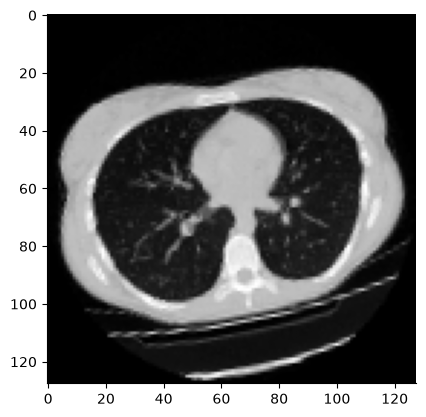

In [15]:
images, _ = next(iter(train_dataset))
image = images[0].numpy()
print("Dimension of the CT scan is:", image.shape)
plt.imshow(np.squeeze(image[:, :, 30]), cmap="gray")
plt.show()

Since a CT scan has many slices, let's visualize a montage of the slices.

In [16]:
def plot_slices(num_rows, num_columns, width, height, data):
    """Plot a montage of num_rows x num_columns CT slices"""
    data = np.rot90(np.array(data))
    data = np.transpose(data)
    data = np.reshape(data, (num_rows, num_columns, width, height))
    rows_data, columns_data = data.shape[0], data.shape[1]
    heights = [slc[0].shape[0] for slc in data]
    widths = [slc.shape[1] for slc in data[0]]
    fig_width = 12.0
    fig_height = fig_width * sum(heights) / sum(widths)
    f, axarr = plt.subplots(
        rows_data,
        columns_data,
        figsize=(fig_width, fig_height),
        gridspec_kw={"height_ratios": heights},
    )
    for i in range(rows_data):
        for j in range(columns_data):
            axarr[i, j].imshow(data[i][j], cmap="gray")
            axarr[i, j].axis("off")
    plt.subplots_adjust(wspace=0, hspace=0, left=0, right=1, bottom=0, top=1)
    plt.show()

Visualize montage of slices.<br>
4 rows and 10 columns for the first 40 slices of the CT scan.

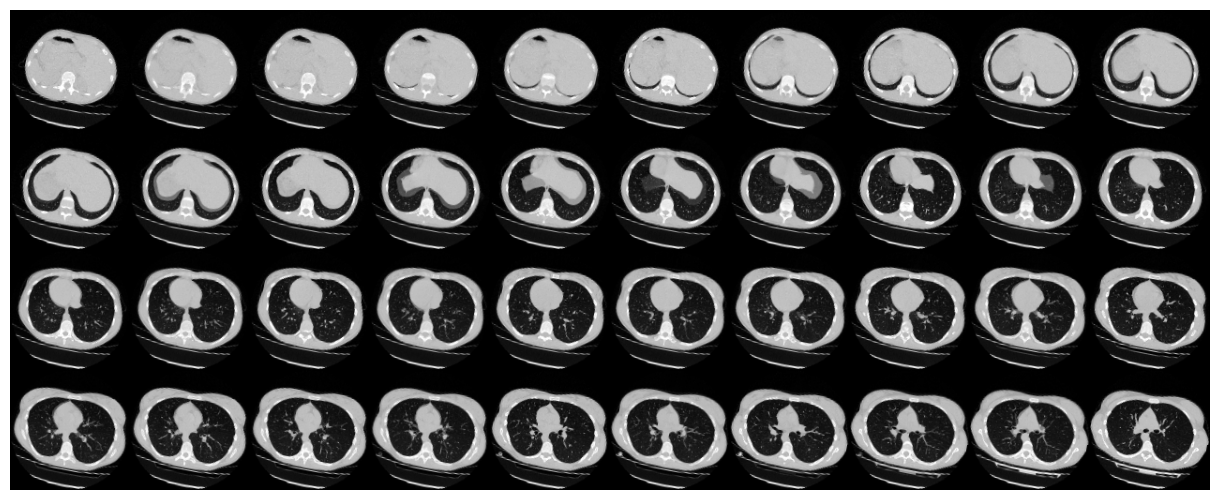

In [17]:
plot_slices(4, 10, WIDTH, HEIGHT, image[:, :, :40, 0])

## Define a 3D convolutional neural network
To make the model easier to understand, we structure it into blocks. The architecture of the 3D CNN used in this example is based on [this paper](https://arxiv.org/abs/2007.13224).

Each block is a 3D convolution, max pooling and group normalization. Group normalization computes its statistics per scan, so unlike batch normalization it doesn't depend on the other scan in a batch of 2. The output layer is always a sigmoid, since the loss is binary cross-entropy.

The tuner can change the hyperparameters that matter most: the number of filters, the dropout rate, the learning rate and the weight decay. Their `default` values define the untuned model. The learning-rate range stops at 5e-4 because a test run at 1e-3 didn't learn. The learning rate decays by 1% every epoch.

In [18]:
def build_model(hp):
    base_filters = hp.Choice("base_filters", [16, 32, 64], default=32)
    dropout = hp.Float("dropout", min_value=0.1, max_value=0.5, step=0.1, default=0.3)
    learning_rate = hp.Float("learning_rate", min_value=3e-5, max_value=5e-4, sampling="log", default=3e-4)
    weight_decay = hp.Float("weight_decay", min_value=1e-6, max_value=1e-3, sampling="log", default=1e-4)

    inputs = keras.Input(shape=(WIDTH, HEIGHT, DEPTH, 1))
    x = inputs
    for filters in (base_filters, base_filters, base_filters * 2, base_filters * 4):
        x = layers.Conv3D(filters, 3, padding="same", kernel_initializer="orthogonal", activation="relu")(x)
        x = layers.MaxPool3D(pool_size=2)(x)
        x = layers.GroupNormalization(groups=8)(x)

    x = layers.GlobalAveragePooling3D()(x)
    x = layers.Dense(base_filters * 8, activation="relu")(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name="3dcnn")
    lr_schedule = keras.optimizers.schedules.ExponentialDecay(
        learning_rate, decay_steps=len(train_dataset), decay_rate=LR_DECAY_PER_EPOCH, staircase=True
    )
    model.compile(
        optimizer=keras.optimizers.AdamW(learning_rate=lr_schedule, weight_decay=weight_decay),
        loss="binary_crossentropy",
        metrics=["accuracy", keras.metrics.AUC(name="auc")],
    )
    return model


build_model(kt.HyperParameters()).summary()

Model: "3dcnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 64,   │             0 │
│                                 │ 1)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d (Conv3D)                 │ (None, 128, 128, 64,   │           896 │
│                                 │ 32)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d (MaxPooling3D)    │ (None, 64, 64, 32, 32) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ group_normalization             │ (None, 64, 64, 32, 32) │            64 │
│ (GroupNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_1 (Conv3D)               │ (None, 64, 64, 32, 32) │        27,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_1 (MaxPooling3D)  │ (None, 32, 32, 16, 32) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ group_normalization_1           │ (None, 32, 32, 16, 32) │            64 │
│ (GroupNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_2 (Conv3D)               │ (None, 32, 32, 16, 64) │        55,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_2 (MaxPooling3D)  │ (None, 16, 16, 8, 64)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ group_normalization_2           │ (None, 16, 16, 8, 64)  │           128 │
│ (GroupNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_3 (Conv3D)               │ (None, 16, 16, 8, 128) │       221,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_3 (MaxPooling3D)  │ (None, 8, 8, 4, 128)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ group_normalization_3           │ (None, 8, 8, 4, 128)   │           256 │
│ (GroupNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling3d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling3D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 339,041 (1.29 MB)

 Trainable params: 339,041 (1.29 MB)

 Non-trainable params: 0 (0.00 B)

## Define callbacks
Early stopping ends training once the validation loss hasn't improved for `patience` epochs. When given paths, `ModelCheckpoint` saves the model from the best epoch (by validation loss) and `CSVLogger` writes the metrics of every epoch to a file, so the training log survives even if the notebook's output is lost.

In [19]:
def make_callbacks(patience, checkpoint_path=None, log_path=None):
    callbacks = [keras.callbacks.EarlyStopping(monitor="val_loss", patience=patience, verbose=1)]
    if checkpoint_path is not None:
        callbacks.append(keras.callbacks.ModelCheckpoint(checkpoint_path, monitor="val_loss", save_best_only=True))
    if log_path is not None:
        callbacks.append(keras.callbacks.CSVLogger(log_path))
    return callbacks

## Tune hyperparameters
A random search trains `TUNING_TRIALS` configurations for up to `TUNING_EPOCHS` epochs each and ranks them by their best validation loss. Trials use the same data, augmentation and early stopping as the final training.

Short trials favor configurations that learn quickly. That is a compromise to keep the search affordable: 10 trials of up to 40 epochs take an estimated 10 hours on an Apple M1. The search only runs when `RUN_TUNING = True`. Results are saved in `tuner_results/ct_classification/`, and with `overwrite=False`, running this cell again continues an interrupted search or reloads a finished one instead of starting over. Delete that folder to search again, for example after changing the model.

In [20]:
tuner = kt.RandomSearch(
    build_model,
    objective="val_loss",
    max_trials=TUNING_TRIALS,
    seed=SEED,
    directory=TUNER_DIR,
    project_name="ct_classification",
    overwrite=False,
)
tuner.search_space_summary()

if RUN_TUNING:
    tuner.search(
        train_dataset,
        validation_data=val_dataset,
        epochs=TUNING_EPOCHS,
        callbacks=make_callbacks(TUNING_PATIENCE),
        verbose=2,
    )

tuner.results_summary(num_trials=5)

Reloading Tuner from tuner_results/ct_classification/tuner0.json
Search space summary
Default search space size: 4
base_filters (Choice)
{'default': 32, 'conditions': [], 'values': [16, 32, 64], 'ordered': True}
dropout (Float)
{'default': 0.3, 'conditions': [], 'min_value': 0.1, 'max_value': 0.5, 'step': 0.1, 'sampling': 'linear'}
learning_rate (Float)
{'default': 0.0003, 'conditions': [], 'min_value': 3e-05, 'max_value': 0.0005, 'step': None, 'sampling': 'log'}
weight_decay (Float)
{'default': 0.0001, 'conditions': [], 'min_value': 1e-06, 'max_value': 0.001, 'step': None, 'sampling': 'log'}
Results summary
Results in tuner_results/ct_classification
Showing 5 best trials
Objective(name="val_loss", direction="min")

Trial 09 summary
Hyperparameters:
base_filters: 64
dropout: 0.1
learning_rate: 6.439354461656223e-05
weight_decay: 3.294740703994362e-05
Score: 0.5861220359802246

Trial 02 summary
Hyperparameters:
base_filters: 32
dropout: 0.2
learning_rate: 0.000470460228420843
weight_dec

## Train the final model
We rebuild the best configuration of the search and train it from scratch for up to `MAX_EPOCHS` epochs, since the search trains each trial only briefly. If there are no search results, the final model uses the default hyperparameters.

The model from the epoch with the lowest validation loss is saved to `models/ct_classification_3d.keras`.

In [21]:
best_hps = tuner.get_best_hyperparameters(num_trials=1)
if best_hps:
    best_hp = best_hps[0]
else:
    print("No tuning results found, so the final model uses the default hyperparameters.")
    best_hp = kt.HyperParameters()

keras.utils.set_random_seed(SEED)
model = build_model(best_hp)
print(best_hp.values)

MODEL_DIR.mkdir(exist_ok=True)
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=MAX_EPOCHS,
    callbacks=make_callbacks(PATIENCE, MODEL_PATH, LOG_PATH),
    verbose=2,
)

{'base_filters': 64, 'dropout': 0.1, 'learning_rate': 6.439354461656223e-05, 'weight_decay': 3.294740703994362e-05}


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


Epoch 1/200
60/60 - 153s - 3s/step - accuracy: 0.5500 - auc: 0.5329 - loss: 0.7579 - val_accuracy: 0.5000 - val_auc: 0.6987 - val_loss: 0.6977
Epoch 2/200
60/60 - 141s - 2s/step - accuracy: 0.9667 - auc: 0.9975 - loss: 0.0966 - val_accuracy: 0.7500 - val_auc: 0.8413 - val_loss: 0.5776
Epoch 113/200
60/60 - 141s - 2s/step - accuracy: 0.9667 - auc: 0.9983 - loss: 0.0941 - val_accuracy: 0.7250 - val_auc: 0.8438 - val_loss: 0.5898
Epoch 114/200
60/60 - 141s - 2s/step - accuracy: 0.9917 - auc: 0.9994 - loss: 0.0802 - val_accuracy: 0.7250 - val_auc: 0.8425 - val_loss: 0.5469
Epoch 115/200
60/60 - 141s - 2s/step - accuracy: 0.9833 - auc: 1.0000 - loss: 0.0683 - val_accuracy: 0.7500 - val_auc: 0.8500 - val_loss: 0.5851
Epoch 116/200
60/60 - 141s - 2s/step - accuracy: 1.0000 - auc: 1.0000 - loss: 0.0688 - val_accuracy: 0.7250 - val_auc: 0.8462 - val_loss: 0.6555
Epoch 117/200
60/60 - 142s - 2s/step - accuracy: 0.9667 - auc: 0.9964 - loss: 0.0925 - val_accuracy: 0.6500 - val_auc: 0.8238 - val_lo

## Visualizing model performance
Here the loss, accuracy and ROC AUC for the training and the validation sets are plotted. The vertical line marks the epoch with the lowest validation loss, which is the one that was saved.

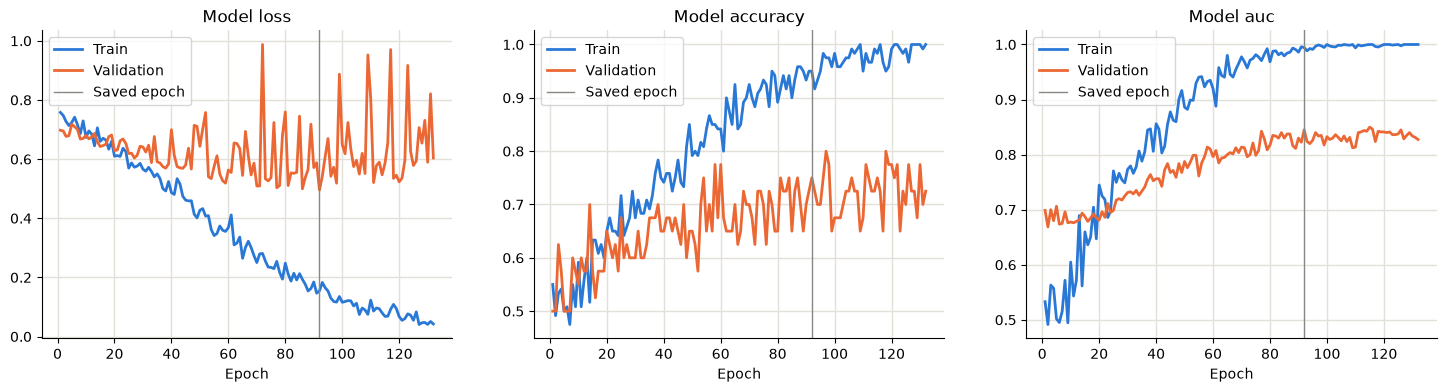

In [22]:
def plot_history(history):
    epochs = np.arange(1, len(history["loss"]) + 1)
    best_epoch = epochs[np.argmin(history["val_loss"])]
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    for ax, metric in zip(axes, ["loss", "accuracy", "auc"]):
        ax.plot(epochs, history[metric], color=BLUE, label="Train")
        ax.plot(epochs, history["val_" + metric], color=ORANGE, label="Validation")
        ax.axvline(best_epoch, color=INK_MUTED, linewidth=1, label="Saved epoch")
        ax.set_title("Model {}".format(metric))
        ax.set_xlabel("Epoch")
        ax.grid(color=GRID_COLOR, linewidth=1)
        ax.set_axisbelow(True)
        ax.legend()
    plt.show()


plot_history(history.history)

## Evaluate the model on the test set
We load the saved model and score it on the test scans, which played no part in training, early stopping or the hyperparameter search.

Accuracy alone hides what kind of mistakes a classifier makes, so we also report:

* **sensitivity**: the share of abnormal scans the model flags as abnormal,
* **specificity**: the share of normal scans the model calls normal,
* **ROC AUC**: the probability that a random abnormal scan gets a higher score than a random normal one, which doesn't depend on the 0.5 threshold.

The 95% confidence intervals come from resampling the test scans with replacement 2,000 times, within each class.

In [23]:
def evaluate(y_true, proba, n_boot=2000):
    """Metrics at a 0.5 threshold, with 95% bootstrap confidence intervals"""

    def score(idx):
        y, predicted = y_true[idx], proba[idx] >= 0.5
        return pd.Series(
            {
                "accuracy": (predicted == y).mean(),
                "sensitivity": predicted[y == 1].mean(),
                "specificity": (~predicted[y == 0]).mean(),
                "roc_auc": metrics.roc_auc_score(y, proba[idx]),
            }
        )

    rng = np.random.default_rng(SEED)
    classes = [np.flatnonzero(y_true == label) for label in (0, 1)]
    boot = pd.DataFrame(
        [score(np.concatenate([rng.choice(idx, size=len(idx)) for idx in classes])) for _ in range(n_boot)]
    )
    return pd.DataFrame(
        {
            "estimate": score(np.arange(len(y_true))),
            "ci_low": boot.quantile(0.025),
            "ci_high": boot.quantile(0.975),
        }
    ).round(3)


model = keras.models.load_model(MODEL_PATH)
y_test = labels[test_idx]
test_proba = model.predict(test_dataset, verbose=0).ravel()
evaluate(y_test, test_proba)

,estimate,ci_low,ci_high
accuracy,0.675,0.525,0.800
sensitivity,0.550,0.350,0.750
specificity,0.800,0.600,0.950
roc_auc,0.787,0.620,0.925


The confusion matrix shows the counts behind the sensitivity and specificity, and the ROC curve shows the trade-off between them at every threshold.

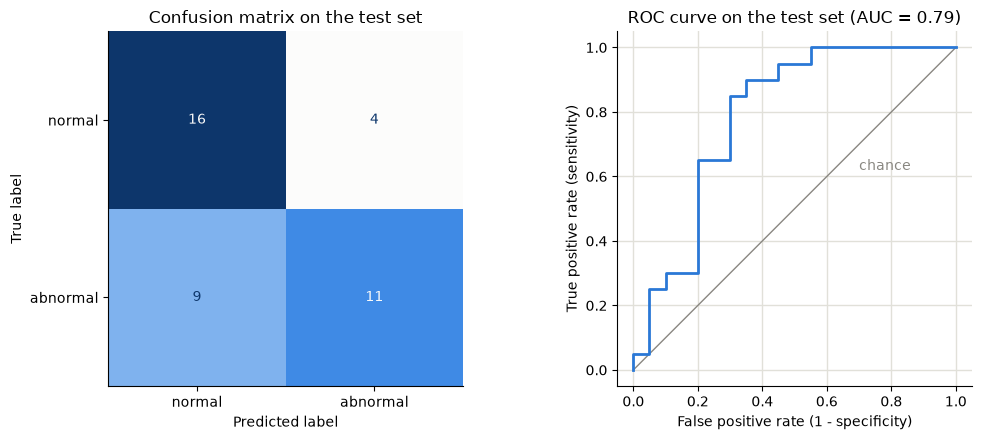

In [24]:
fig, (ax_cm, ax_roc) = plt.subplots(1, 2, figsize=(11, 4.5))

metrics.ConfusionMatrixDisplay.from_predictions(
    y_test,
    (test_proba >= 0.5).astype(int),
    labels=[0, 1],
    display_labels=CLASS_NAMES,
    cmap=SEQUENTIAL_CMAP,
    colorbar=False,
    ax=ax_cm,
)
ax_cm.set_title("Confusion matrix on the test set")

fpr, tpr, _ = metrics.roc_curve(y_test, test_proba)
ax_roc.plot([0, 1], [0, 1], color=INK_MUTED, linewidth=1)
ax_roc.plot(fpr, tpr, color=BLUE)
ax_roc.text(0.7, 0.62, "chance", color=INK_MUTED)
ax_roc.set_aspect("equal")
ax_roc.set_xlabel("False positive rate (1 - specificity)")
ax_roc.set_ylabel("True positive rate (sensitivity)")
ax_roc.set_title(f"ROC curve on the test set (AUC = {metrics.roc_auc_score(y_test, test_proba):.2f})")
ax_roc.grid(color=GRID_COLOR, linewidth=1)
ax_roc.set_axisbelow(True)

fig.tight_layout()
plt.show()

It is important to note that the number of samples is very small (only 200), so each of the validation and test sets has 40 scans. One scan is worth 2.5 points of accuracy, which is why the confidence intervals above are wide, and a different seed for the split can move the results by several points. The full dataset which consists of over 1000 CT scans can be found [here](https://www.medrxiv.org/content/10.1101/2020.05.20.20100362v1). Using the full dataset, an accuracy of 83% was achieved. A variability of 6-7% in the classification performance is observed in both cases.

## Make predictions on a single CT scan

In [25]:
scan = test_idx[0]
prediction = model.predict(volumes[scan][np.newaxis, ..., np.newaxis], verbose=0)[0, 0]
scores = [1 - prediction, prediction]

for score, name in zip(scores, CLASS_NAMES):
    print("This model is %.2f percent confident that CT scan is %s" % ((100 * score), name))
print("The scan is labeled %s" % CLASS_NAMES[labels[scan]])

This model is 31.89 percent confident that CT scan is normal
This model is 68.11 percent confident that CT scan is abnormal
The scan is labeled normal
